## 1. Carga de librerías y dataset
En este bloque se importan las librerías clave para el análisis y se prepara la lectura del dataset con **pathlib.Path**, una opción más robusta que strings en rutas de Windows. También se valida la carga comprobando la dimensión del DataFrame, lo que asegura que la fuente está lista para trabajar. El dataset contiene **1,460 transacciones inmobiliarias reales** de Ames, Iowa, con **81 atributos por propiedad**, un volumen suficiente para construir un modelo de tasación con utilidad en decisiones de **compra**, **venta** y **valoración** residencial.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [3]:
data_path = Path("../../data/train.csv")
df = pd.read_csv(data_path)
print(df)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fe

In [10]:
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas: 1460
Columnas: 81


## 2. Inspección inicial de estructura y variable objetivo
Aquí se realiza una revisión rápida de la estructura real de los datos para detectar problemas tempranos: con **head()** se observan ejemplos de registros, con **info()** se validan tipos de dato y conteos de no nulos, y con **describe()** sobre **SalePrice** se obtiene el perfil estadístico del objetivo. La lectura de negocio muestra una **media de 180,921 USD** y una **mediana de 163,000 USD**; esta brecha sugiere propiedades de alto valor que empujan el promedio. Si se usara solo la media como referencia de mercado, se podría sobreestimar el valor típico en aproximadamente **18,000 USD**.

In [23]:
# Muestra las primeras 5 filas del dataset
# Permite ver la estructura real de los datos
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
# Información estructural del DataFrame
# Muestra: nombre de columna, cantidad de non-null values y dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. Diagnóstico de valores faltantes
En este bloque se cuantifican y ordenan las columnas con nulos para priorizar el tratamiento previo al modelado. Se detectan **19 columnas con valores faltantes**, destacando **PoolQC (1,453)**, **MiscFeature (1,406)** y **Alley (1,369)**. Desde negocio, estos nulos reflejan en gran parte **ausencia real de características** (por ejemplo, no tener piscina o callejón) y no pérdida de información; por eso, la decisión correcta es codificar la ausencia como categoría válida en lugar de eliminar registros.

In [16]:
# Cuenta los nulos por columna y filtra solo las que tienen al menos 1
# .isnull() retorna True/False por cada celda
# .sum() suma los True (los nulos)
# sort_values ordena de mayor a menor para ver los más críticos primero
nulos = df.isnull().sum()
nulos[nulos > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [13]:
# Estadística descriptiva de variables numéricas
# count, mean, std, min, percentiles, max
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Se plantea la hipotesis de que la diferencia positiva entre la media y la mediana de **SalePrice** se debe a la presencia de propiedades de alto valor que elevan el promedio, mientras que la mayoría de las propiedades tienen precios más bajos, lo que se refleja en la mediana. Esto sugiere una distribución sesgada hacia la derecha, común en datos inmobiliarios, donde unas pocas propiedades muy caras pueden influir significativamente en la media.

In [17]:
# Accede a una columna específica y aplica describe()
# Los corchetes seleccionan la columna como una Serie
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 4. Distribución y outliers de SalePrice
Se visualiza **SalePrice** con histograma y boxplot para entender concentración, dispersión y valores extremos. El análisis muestra mayor densidad entre **100,000 y 200,000 USD** y una cola derecha marcada. El boxplot confirma que el **50%** de las transacciones se concentra entre **129,975 y 214,000 USD** (IQR), con observaciones máximas muy por encima del rango central. Estos **outliers** deben conservarse porque representan el segmento premium, relevante para estrategias de inversión y valuación de activos de alto ticket.

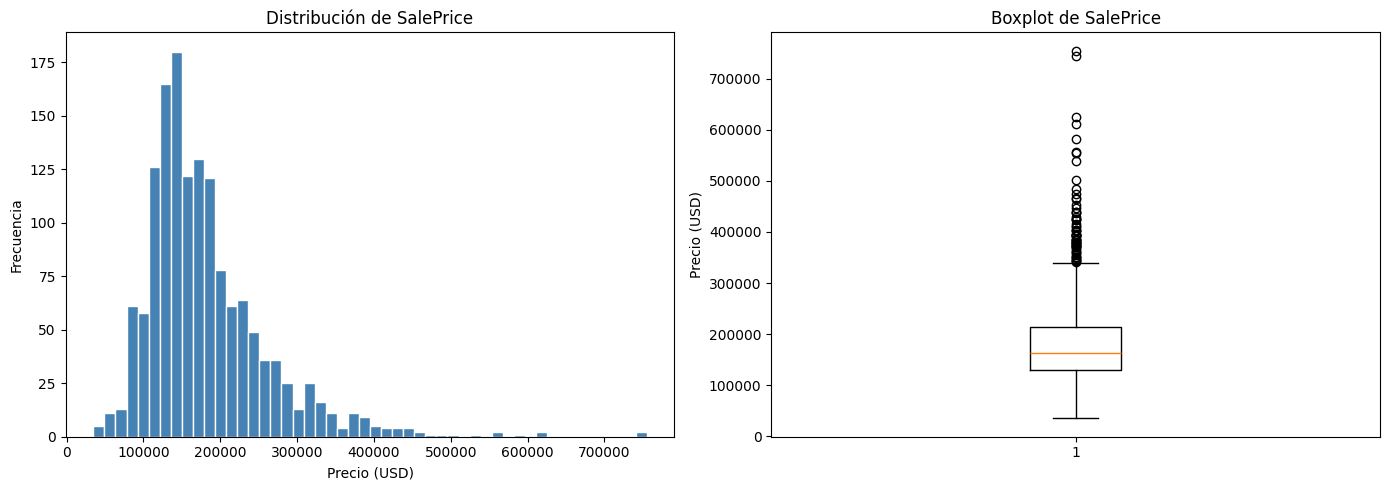

In [16]:
# Figura con dos subplots lado a lado
# Crea un lienzo plt.subplots(filas,columnas, figsize=(ancho,alto))
# El resultado es fig (lienzo completo) y axes (arreglo con los dos espacios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma de SalePrice ---
# Para este grafico se selecciona el primer espacio dentro del arreglo axes
# bins=50 divide el rango en 50 barras para ver la forma real, color= Color de las barras
# edgecolor= Color del borde las barras
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
# Estos 3 parametros se usaran practicamente en cada grafico
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# --- Boxplot de SalePrice ---
# Para este grafico se selecciona el segundo espacio dentro del arreglo axes
# Muestra mediana, cuartiles y outliers visualmente
axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()  # Ajusta espacios automáticamente para que no se encimen
plt.show()          # Renderiza y muestra el gráfico

## 5. Validación de normalidad de SalePrice
Este bloque evalúa si **SalePrice** cumple normalidad, supuesto clave para regresión lineal. La superposición de histograma en densidad con curva **KDE** muestra una distribución asimétrica, y el **Q-Q Plot** evidencia desviaciones en la cola superior frente a una normal teórica. La conclusión es que **SalePrice no sigue distribución normal**; sin corrección, un modelo lineal puede sesgar estimaciones y subestimar propiedades premium, elevando riesgo en decisiones de crédito e inversión.

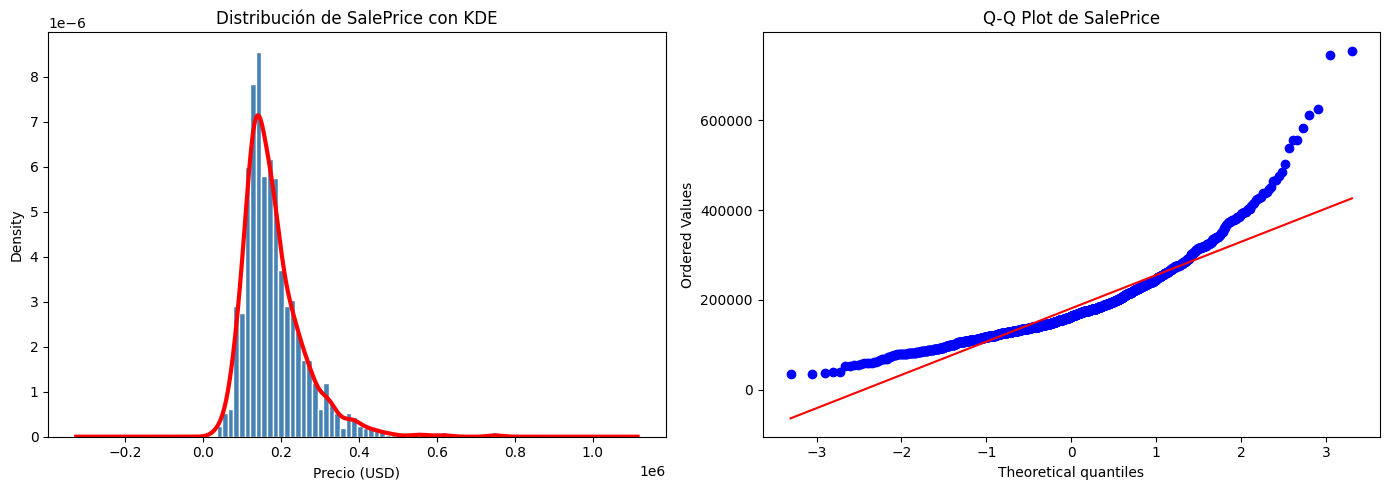

In [22]:
#Nuevamente se genera una grafica con dos lienzos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con dos capas:
# density=True normaliza el eje Y para que sea compatible con la curva KDE
# kind='hist' dibuja las barras
df['SalePrice'].plot(kind='hist', bins=50, density=True,
                     ax=axes[0], color='steelblue', edgecolor='white')

# kind='kde' superpone la curva de densidad estimada sobre el histograma
df['SalePrice'].plot(kind='kde', ax=axes[0], color='red', linewidth=3)
axes[0].set_title('Distribución de SalePrice con KDE')
axes[0].set_xlabel('Precio (USD)')

# Q-Q Plot: compara tu distribución contra una normal teórica
# Si los puntos siguen la línea — distribución normal
# Si se desvían en los extremos — hay sesgo
stats.probplot(df['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q Plot de SalePrice')

plt.tight_layout()
plt.show()

## 6. Transformación logarítmica del precio
Se aplica **np.log()** a **SalePrice** para reducir la influencia de extremos y aproximar la distribución a una forma más simétrica. La comparación visual entre distribución original y transformada muestra una cola derecha comprimida y una densidad más cercana a campana. En términos de negocio, esta transformación modela mejor variaciones **relativas** del mercado inmobiliario; por ello, el entrenamiento se hace sobre **SalePrice_log** y luego las predicciones se devuelven a USD con **np.exp()**.

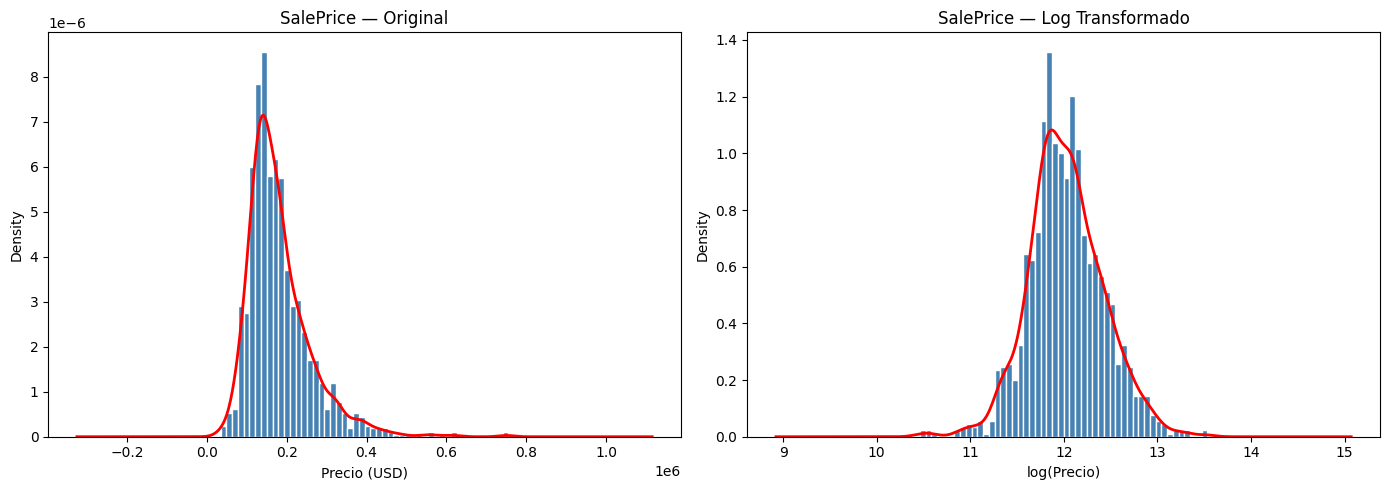

In [23]:
# Aplicamos logaritmo natural a SalePrice
# np.log() es logaritmo natural — comprime valores extremos
df['SalePrice_log'] = np.log(df['SalePrice'])

# Comparamos distribución original vs transformada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
df['SalePrice'].plot(kind='hist', bins=50, density=True,
                    ax=axes[0], color='steelblue', edgecolor='white')
df['SalePrice'].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].set_title('SalePrice — Original')
axes[0].set_xlabel('Precio (USD)')

# Distribución transformada
df['SalePrice_log'].plot(kind='hist', bins=50, density=True,
                         ax=axes[1], color='steelblue', edgecolor='white')
df['SalePrice_log'].plot(kind='kde', ax=axes[1], color='red', linewidth=2)
axes[1].set_title('SalePrice — Log Transformado')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

## 7. Correlaciones clave con SalePrice
Aquí se calcula la **correlación de Pearson** entre variables numéricas y **SalePrice** para priorizar predictores de alto impacto. El orden por valor absoluto permite captar relaciones fuertes positivas o negativas. Los hallazgos más relevantes indican que **OverallQual (~0.79)**, **GrLivArea (~0.71)** y **GarageArea (~0.62)** son impulsores principales del precio; además, **YearBuilt (~0.52)** confirma que la antigüedad influye de forma material en el valor de mercado.

In [24]:
# Seleccionamos solo columnas numéricas del DataFrame
# select_dtypes filtra por tipo de dato
numericas = df.select_dtypes(include=[np.number])

# Calculamos correlación de Pearson entre todas las variables numéricas
# .corr() retorna una matriz de NxN donde N = número de columnas numéricas
correlacion = numericas.corr()

# Extraemos solo la correlación contra SalePrice y ordenamos de mayor a menor
# abs() toma el valor absoluto — correlaciones negativas también importan
correlacion_target = correlacion['SalePrice'].abs().sort_values(ascending=False)

# Mostramos las 15 variables más correlacionadas con SalePrice
print(correlacion_target.head(15))

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
Name: SalePrice, dtype: float64


## 8. Matriz de correlación y control de multicolinealidad
Se construye una matriz de correlación sobre variables numéricas top para detectar **multicolinealidad** y reducir redundancia del modelo. Se excluyen **SalePrice** y **SalePrice_log** por su relación directa y trivial entre sí. El análisis permite sostener decisiones de depuración como conservar **GarageArea** frente a **GarageCars**, **GrLivArea** frente a **TotRmsAbvGrd**, y **YearBuilt** frente a **GarageYrBlt**, mejorando estabilidad e interpretabilidad sin sacrificar capacidad predictiva.

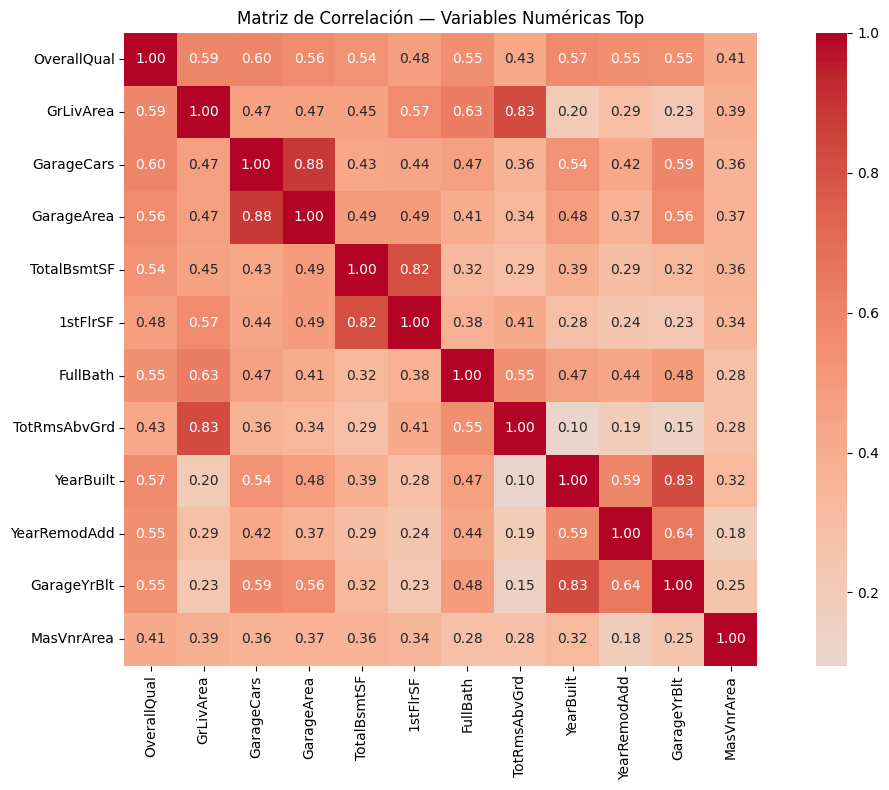

In [25]:
# Seleccionamos las 15 variables más correlacionadas con SalePrice
# Excluimos SalePrice_log porque es derivada directa del target
top_vars = correlacion_target.drop(['SalePrice', 'SalePrice_log']).head(12).index

# Calculamos correlación entre esas variables — no contra el target
# sino entre ellas mismas
corr_matrix = numericas[top_vars].corr()

# Visualizamos con heatmap
plt.figure(figsize=(12, 8))

# annot=True muestra los valores numéricos dentro de cada celda
# fmt='.2f' formatea a 2 decimales
# cmap define la paleta de colores — rojo alto, azul bajo
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Matriz de Correlación — Variables Numéricas Top')
plt.tight_layout()
plt.show()

In [ ]:
# Lista de variables categóricas de calidad a evaluar
vars_categoricas_todas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Total variables categóricas: {len(vars_categoricas_todas)}')
print(vars_categoricas_todas)

# Para cada variable calculamos el F-statistic del ANOVA
# F alto y p-value bajo significa que la variable SÍ diferencia precios significativamente
resultados = []

for var in vars_categoricas_todas:
    # Eliminamos nulos para esa variable
    df_temp = df[['SalePrice', var]].dropna()
    
    # Agrupamos SalePrice por cada categoría de la variable
    grupos = [grupo['SalePrice'].values 
              for _, grupo in df_temp.groupby(var)]
    
    # ANOVA de un factor
    f_stat, p_value = stats.f_oneway(*grupos)
    
    resultados.append({
        'Variable': var,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6)
    })

# Convertimos a DataFrame y ordenamos por F-Statistic
resultados_df = pd.DataFrame(resultados).sort_values('F-Statistic', ascending=False)
print(resultados_df.head(10))

Total variables categóricas: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
        Variable  F-Statistic  P-Value
18     ExterQual       443.33      0.0
30   KitchenQual       407.81      0.0
21      BsmtQual       392.91      0.0
34  GarageFinish       250.96      0.0
20    Foundation       100.25      0.0
28    CentralAir        98.31      0.0
27     HeatingQC        88.39      0.0
8   Neighborhood        71.78      0.0
33    GarageType        71.52      0.